In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

Loading the data and getting familiar with it.

In [13]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = pd.read_csv(data_path)

df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03
mean,145.515545,146.681738,144.471597,145.617278,5.773301e+06
std,37.554946,37.613446,37.477641,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.405000,117.765000,115.490000,116.525000,3.622681e+06
50%,149.610000,150.330000,148.470000,149.315000,4.928852e+06
75%,178.445000,179.762500,177.330000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


Data preprocessing

In [14]:
# Filling missing dates with the previous day's values
first_date = df['Date'].min()
last_date = df['Date'].max()

for single_date in pd.date_range(start=first_date, end=last_date):
    if single_date.strftime('%Y-%m-%d') not in df['Date'].values:
        previous_date = (single_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        previous_row = df[df['Date'] == previous_date]
        new_row = previous_row.copy()
        new_row['Date'] = single_date.strftime('%Y-%m-%d')
        df = pd.concat([df, new_row], ignore_index=True)
df = df.sort_values(by='Date').reset_index(drop=True)

# Find missing values in the data
missing_values = df.isnull().sum()
print("Missing values in each column:") 
print(missing_values)

# Fill missing values with previous day's values
df.fillna(method='ffill', inplace=True)

Missing values in each column:
Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64


C:\Users\eknut\AppData\Local\Temp\ipykernel_2320\3931841901.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Extracting trend, seasonality and residuals from the time series data.

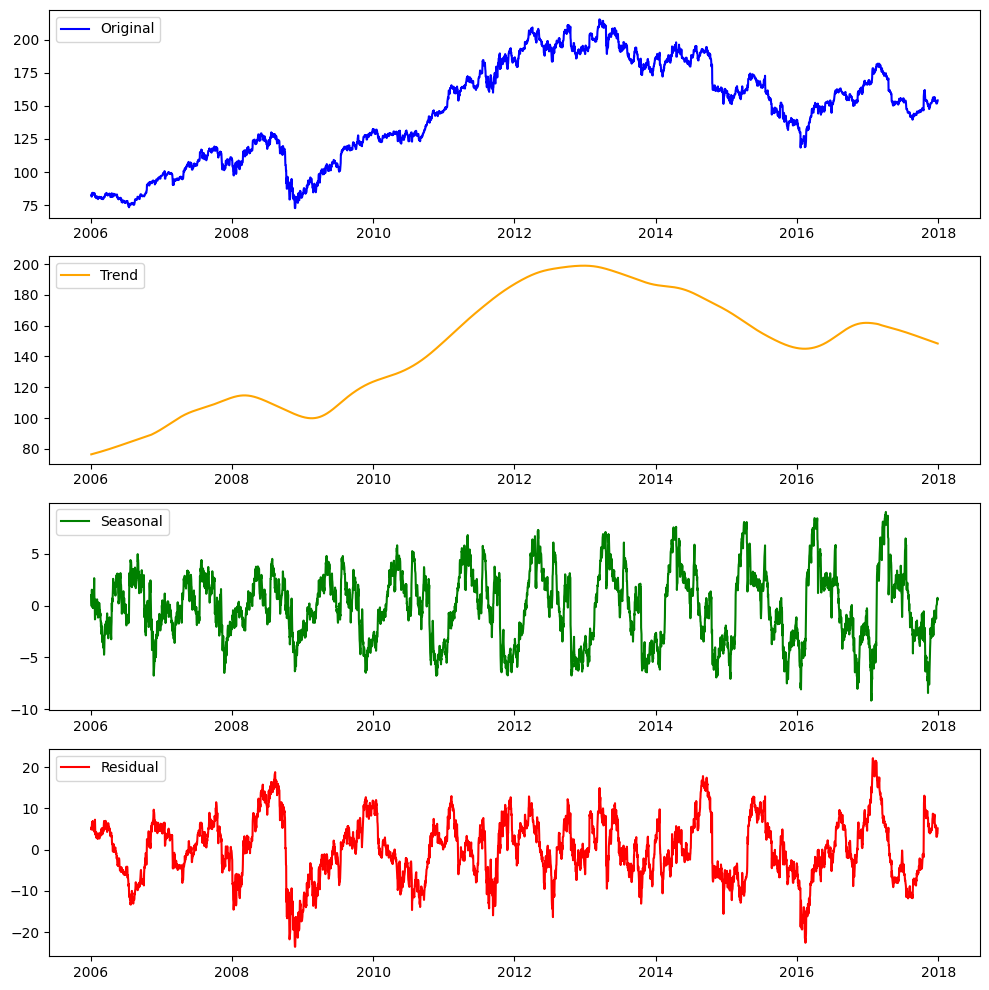

In [25]:
dates = pd.to_datetime(df['Date'])
series = df["Open"]

stl = STL(series, period=365, seasonal=13)

res = stl.fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

plt.figure(figsize=(10, 10))
plt.subplot(4, 1, 1)
plt.plot(dates, series, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(dates, trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(dates, seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(dates, resid, label='Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Plotting raw data for opening prices and volumes.

## Weekly Seasonality Analysis

Since we have complete daily data, we can examine weekly patterns that might be missed by annual seasonality.

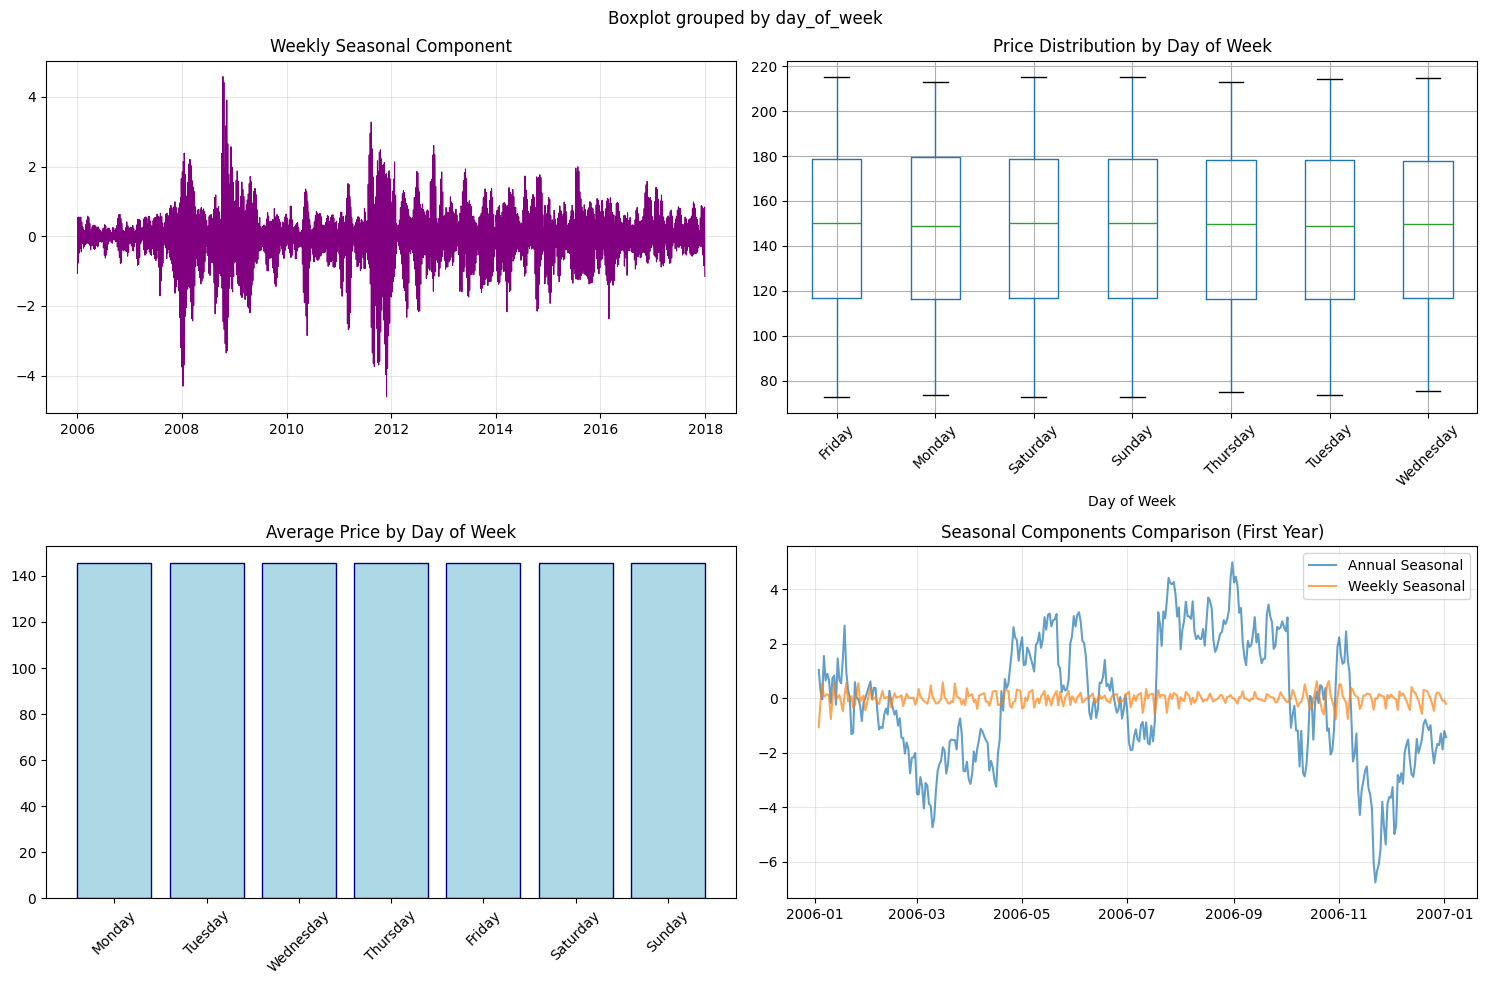

Day of Week Statistics:
day_of_week
Friday       145.561454
Saturday     145.547680
Sunday       145.547680
Thursday     145.512316
Wednesday    145.498914
Monday       145.463840
Tuesday      145.410687
Name: price, dtype: float64


In [16]:
# Weekly seasonality analysis for complete daily data
from statsmodels.tsa.seasonal import STL

# Extract weekly patterns (7-day cycle)
stl_weekly = STL(series, period=7, seasonal=7, robust=True)
res_weekly = stl_weekly.fit()

# Create day-of-week analysis
df_daily = pd.DataFrame({
    'date': dates,
    'price': series.values,
    'day_of_week': dates.dt.day_name(),
    'weekday': dates.dt.weekday  # 0=Monday, 6=Sunday
})

# Weekly seasonality visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weekly decomposition
axes[0, 0].plot(dates, res_weekly.seasonal, color='purple', linewidth=0.8)
axes[0, 0].set_title('Weekly Seasonal Component')
axes[0, 0].grid(True, alpha=0.3)

# Day of week boxplot
df_daily.boxplot(column='price', by='day_of_week', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution by Day of Week')
axes[0, 1].set_xlabel('Day of Week')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# Average price by day of week
daily_avg = df_daily.groupby('day_of_week')['price'].mean()
daily_avg = daily_avg.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
axes[1, 0].bar(daily_avg.index, daily_avg.values, color='lightblue', edgecolor='navy')
axes[1, 0].set_title('Average Price by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=45)

# Weekly vs Annual seasonal comparison
axes[1, 1].plot(dates[:365], seasonal.iloc[:365], label='Annual Seasonal', alpha=0.7)
axes[1, 1].plot(dates[:365], res_weekly.seasonal.iloc[:365], label='Weekly Seasonal', alpha=0.7)
axes[1, 1].set_title('Seasonal Components Comparison (First Year)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Day of Week Statistics:")
print(daily_avg.sort_values(ascending=False))

## Multi-level Seasonal Decomposition

With complete daily data, we can perform hierarchical decomposition to capture multiple seasonal patterns.

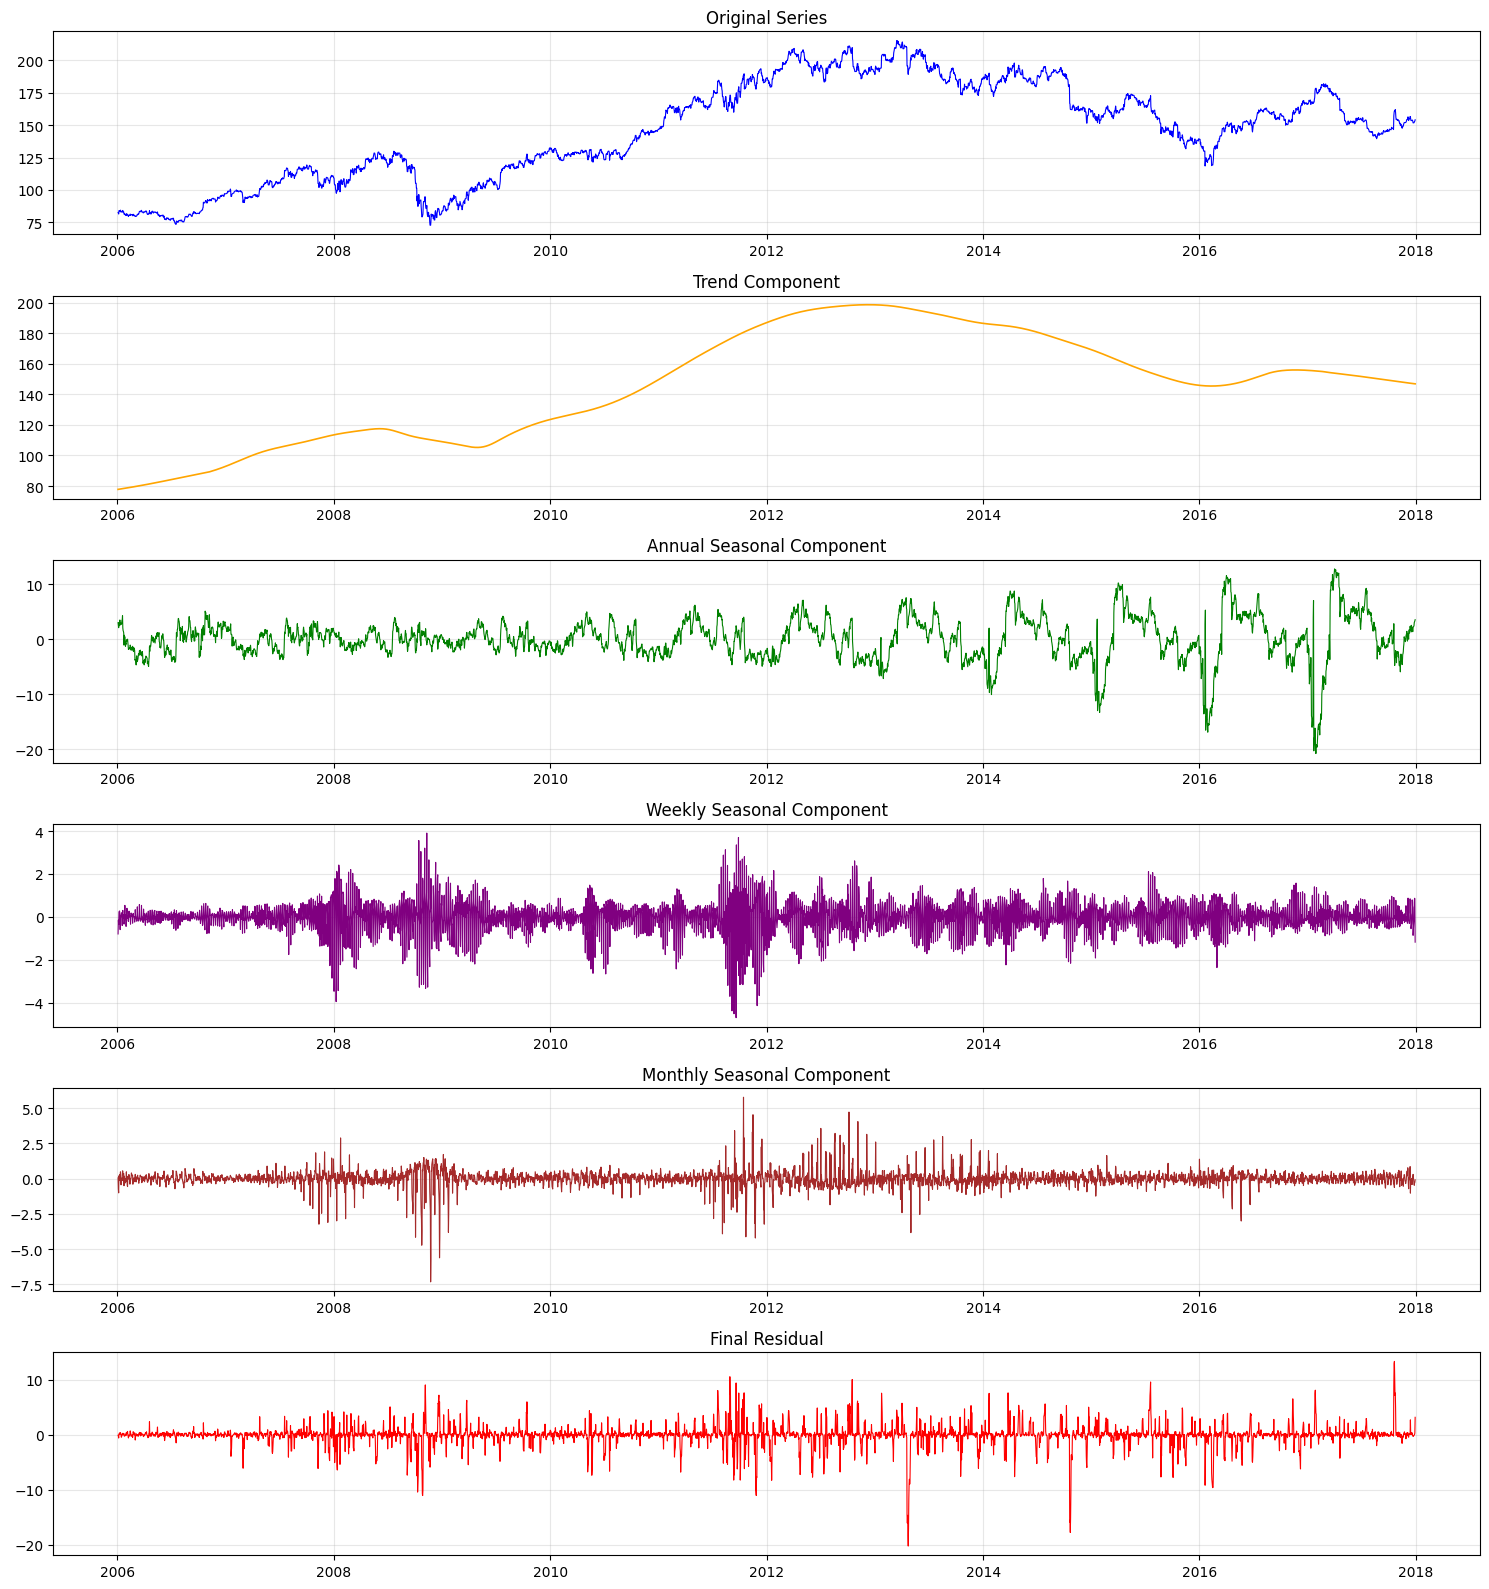

Variance Decomposition:
Total variance: 1410.357353
Trend: 86.77%
Annual seasonality: 1.08%
Weekly seasonality: 0.04%
Monthly patterns: 0.02%
Residual: 0.28%
Total explained: 99.72%


In [17]:
# Multi-level decomposition leveraging complete daily data
def multi_level_decomposition(series, dates):
    """
    Perform multi-level seasonal decomposition for daily financial data
    """
    # Level 1: Remove annual trend
    stl_annual = STL(series, period=365, seasonal=13, robust=True)
    res_annual = stl_annual.fit()
    
    # Level 2: Decompose residuals for weekly patterns
    weekly_residual = res_annual.resid + res_annual.seasonal
    stl_weekly = STL(weekly_residual, period=7, seasonal=7, robust=True)
    res_weekly = stl_weekly.fit()
    
    # Level 3: Check for monthly patterns in remaining residuals
    monthly_residual = res_weekly.resid
    stl_monthly = STL(monthly_residual, period=30, seasonal=7, robust=True)
    res_monthly = stl_monthly.fit()
    
    return {
        'trend': res_annual.trend,
        'annual_seasonal': res_annual.seasonal,
        'weekly_seasonal': res_weekly.seasonal,
        'monthly_seasonal': res_monthly.seasonal,
        'residual': res_monthly.resid,
        'original': series
    }

# Perform multi-level decomposition
decomp = multi_level_decomposition(series, dates)

# Visualize the multi-level decomposition
fig, axes = plt.subplots(6, 1, figsize=(15, 16))

axes[0].plot(dates, decomp['original'], 'b-', linewidth=0.8)
axes[0].set_title('Original Series', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates, decomp['trend'], 'orange', linewidth=1.2)
axes[1].set_title('Trend Component', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(dates, decomp['annual_seasonal'], 'green', linewidth=0.8)
axes[2].set_title('Annual Seasonal Component', fontsize=12)
axes[2].grid(True, alpha=0.3)

axes[3].plot(dates, decomp['weekly_seasonal'], 'purple', linewidth=0.8)
axes[3].set_title('Weekly Seasonal Component', fontsize=12)
axes[3].grid(True, alpha=0.3)

axes[4].plot(dates, decomp['monthly_seasonal'], 'brown', linewidth=0.8)
axes[4].set_title('Monthly Seasonal Component', fontsize=12)
axes[4].grid(True, alpha=0.3)

axes[5].plot(dates, decomp['residual'], 'red', linewidth=0.8)
axes[5].set_title('Final Residual', fontsize=12)
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate variance explained by each component
total_var = decomp['original'].var()
trend_var = decomp['trend'].var()
annual_var = decomp['annual_seasonal'].var()
weekly_var = decomp['weekly_seasonal'].var()
monthly_var = decomp['monthly_seasonal'].var()
residual_var = decomp['residual'].var()

print("Variance Decomposition:")
print(f"Total variance: {total_var:.6f}")
print(f"Trend: {trend_var/total_var:.2%}")
print(f"Annual seasonality: {annual_var/total_var:.2%}")
print(f"Weekly seasonality: {weekly_var/total_var:.2%}")
print(f"Monthly patterns: {monthly_var/total_var:.2%}")
print(f"Residual: {residual_var/total_var:.2%}")
print(f"Total explained: {1 - residual_var/total_var:.2%}")

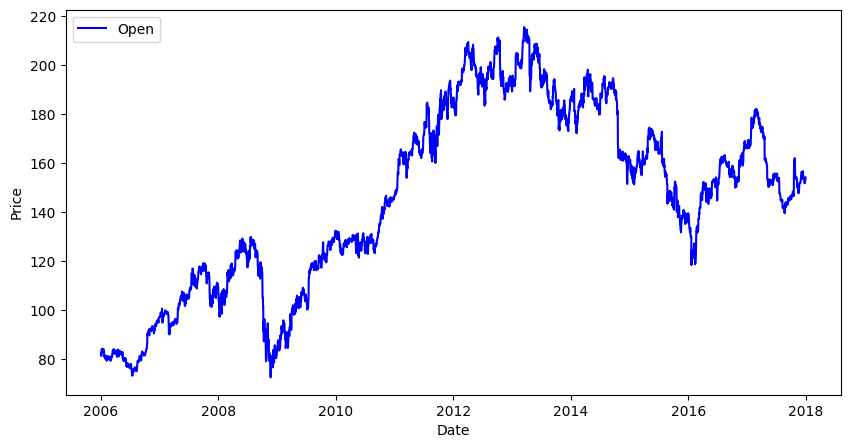

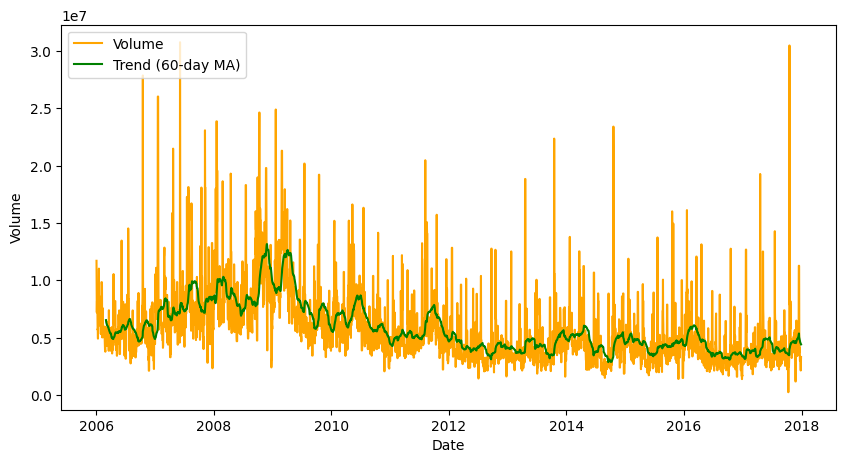

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(dates, series, label='Open', color='blue')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(dates, df['Volume'][series.index], label='Volume', color='orange')
trend_volume = df['Volume'][series.index].rolling(window=60).mean()
plt.plot(dates, trend_volume, label='Trend (60-day MA)', color='green')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(loc='upper left')
plt.show()

Autocorrelation analysis

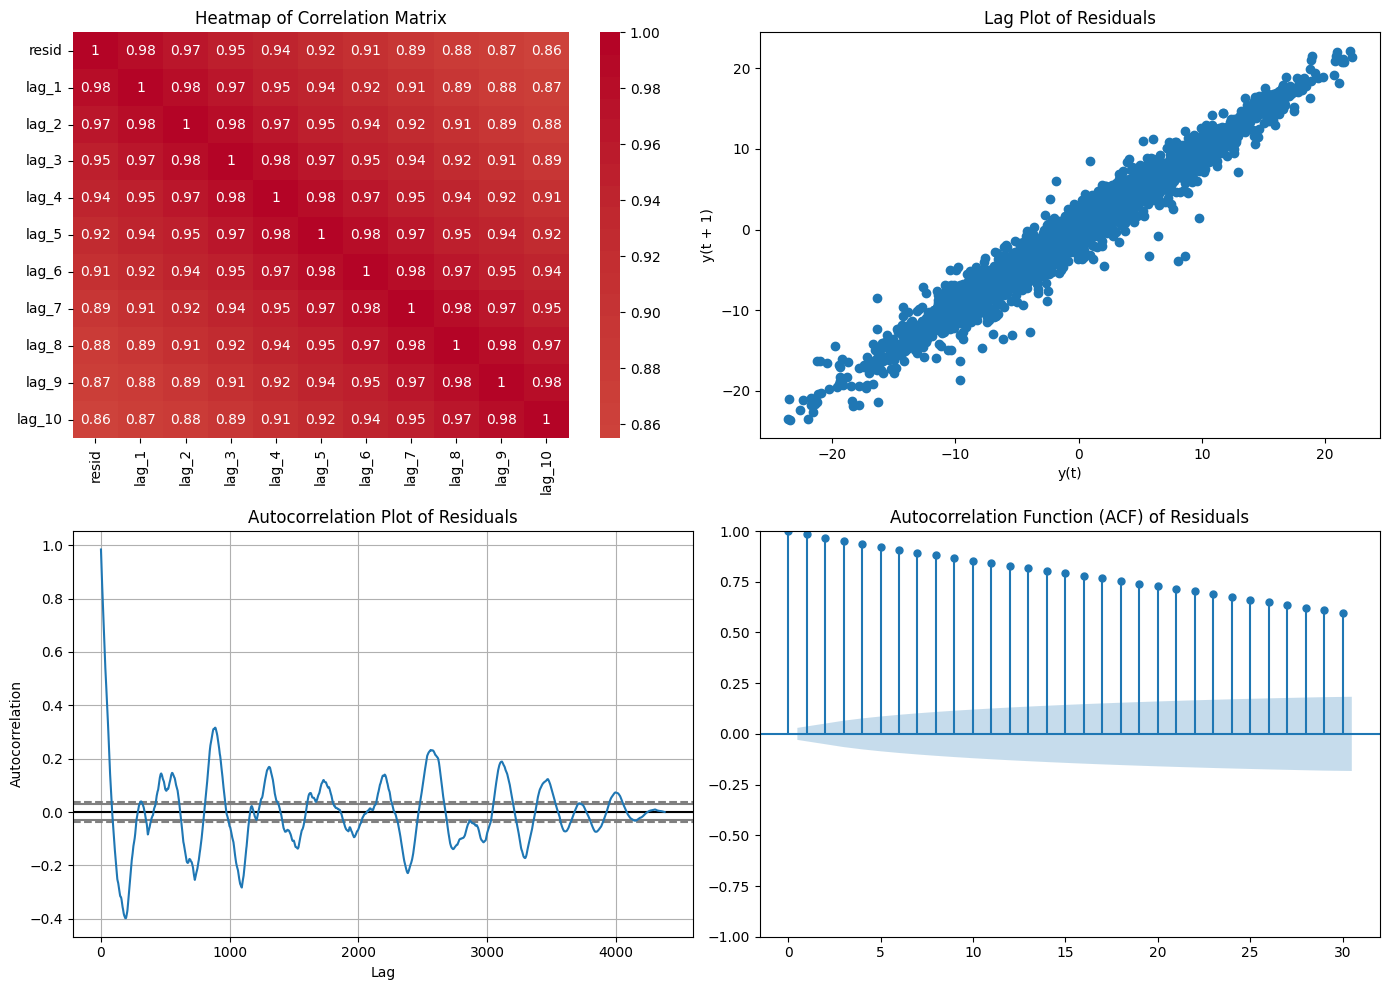

In [19]:
# Create a 1-10 day lagged dataset of the residuals
lagged_resid = pd.DataFrame({'resid': resid})
for i in range(1, 11):
    lagged_resid[f'lag_{i}'] = lagged_resid['resid'].shift(i)
lagged_resid = lagged_resid.dropna()

# Compute the correlation matrix
corr = lagged_resid.corr()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix')

# Lag plot
pd.plotting.lag_plot(resid, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Residuals')

# Autocorrelation plot
pd.plotting.autocorrelation_plot(resid, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Residuals')

# ACF (from statsmodels)
plot_acf(resid, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Residuals')

plt.tight_layout()
plt.show()

Analyze returns

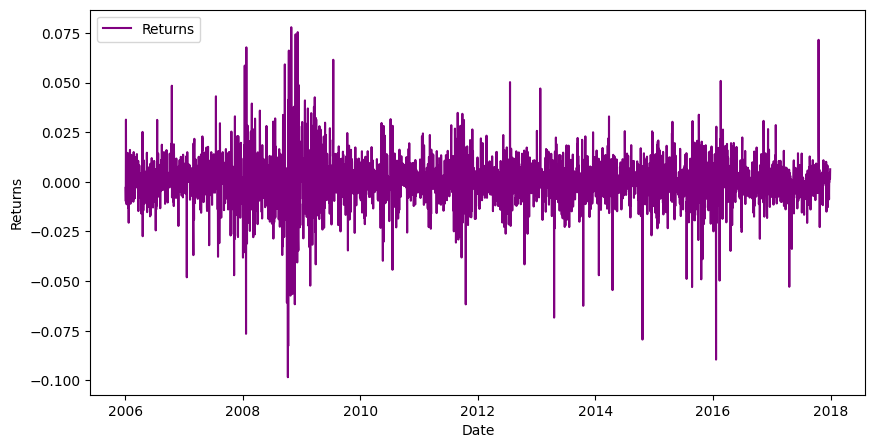

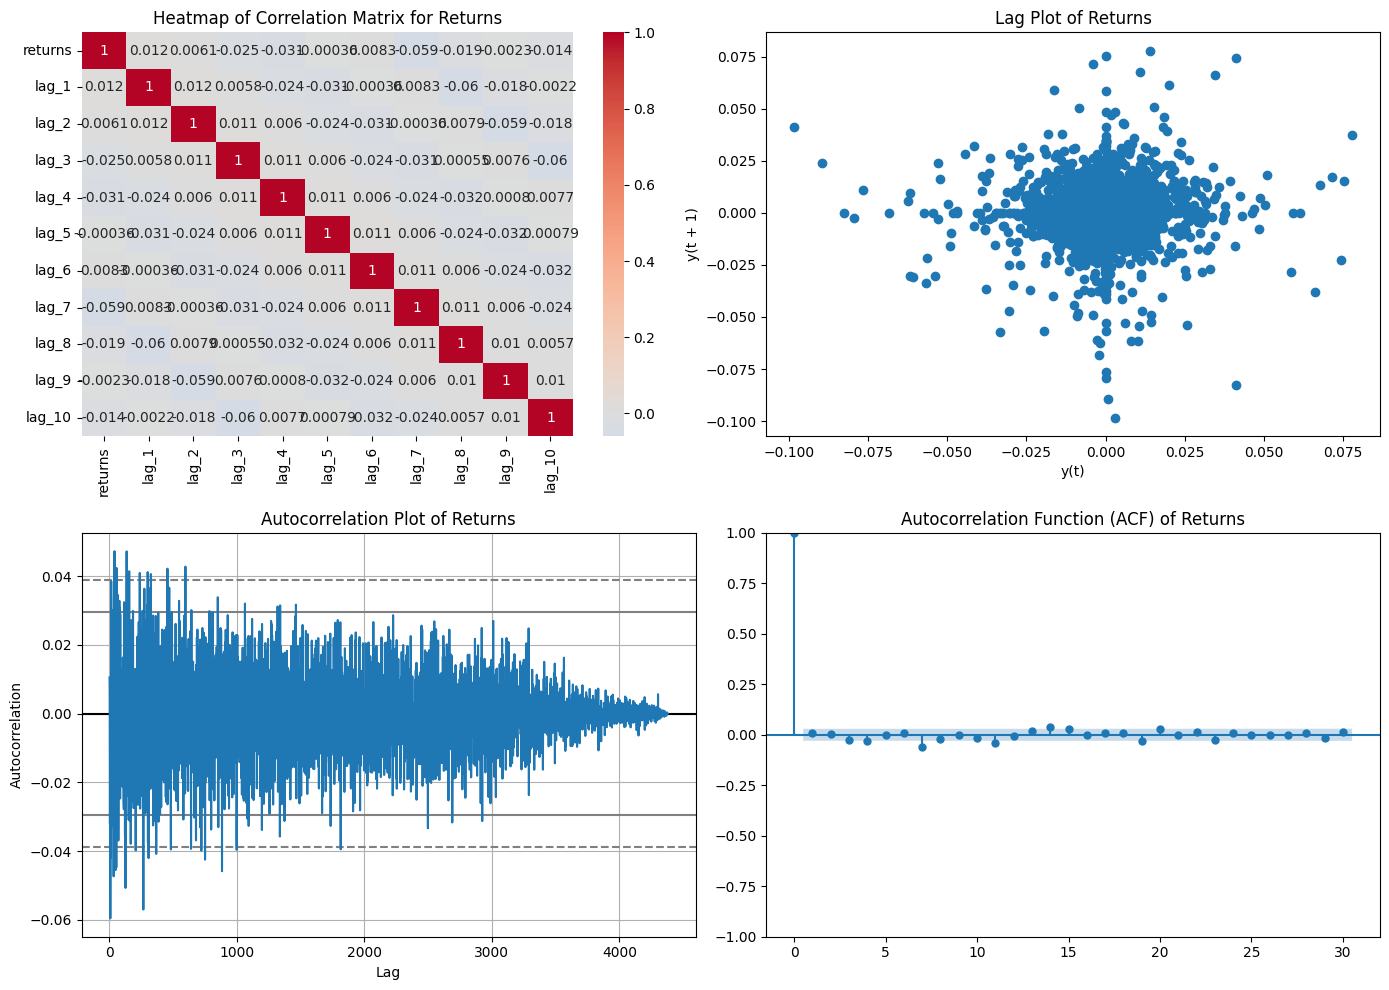

In [20]:
# Calculate returns
returns = series.pct_change().dropna()
plt.figure(figsize=(10, 5))
plt.plot(dates[1:], returns, label='Returns', color='purple')
# plt.title('Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

# Autocorrelation of returns
# Create a 1-10 day lagged dataset
lagged_returns = pd.DataFrame({'returns': returns})
for i in range(1, 11):
    lagged_returns[f'lag_{i}'] = lagged_returns['returns'].shift(i)
lagged_returns = lagged_returns.dropna()

# Compute the correlation matrix
corr_returns = lagged_returns.corr()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Heatmap
sns.heatmap(corr_returns, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix for Returns')
# Lag plot
pd.plotting.lag_plot(returns, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Returns')
# Autocorrelation plot
pd.plotting.autocorrelation_plot(returns, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Returns')
# ACF (from statsmodels)
plot_acf(returns, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Returns')
plt.tight_layout()
plt.show()